In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [3]:
n_train = 50 # 训练样本数
x_train, _ = torch.sort(torch.rand(n_train) * 5) # 训练样本，升序排序

def f(x):
    return 2*torch.sin(x) + x**0.08

y_train = f(x_train) + torch.normal(0.0, 0.5, (n_train, ))
x_test = torch.arange(0, 5, 0.1) # 测试样本
y_truth = f(x_test)
n_test = len(x_test)

In [7]:
def plot_kernel_reg(y_hat):
    d2l.plot(x_test, [y_truth, y_hat], 'x', 'y', legend=['Truth', 'Pred'], xlim=[0, 5], ylim=[-1, 5])
    d2l.plt.plot(x_train, y_train, 'o', alpha=0.5)

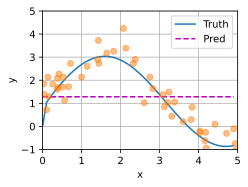

In [8]:
y_hat = torch.repeat_interleave(y_train.mean(), n_test)
plot_kernel_reg(y_hat)

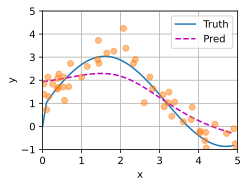

In [9]:
X_repeat = x_test.repeat_interleave(n_train).reshape((-1, n_train))
# X_repeat.shape=(n_test, n_train)
attention_weights = nn.functional.softmax(-(X_repeat-x_train)**2/2, dim=1)
y_hat = torch.matmul(attention_weights, y_train)
plot_kernel_reg(y_hat)

In [ ]:
class NWKernelRegression(nn.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.w = nn.Parameter(torch.rand(1, ) requires_grad=True)

    def forward(self, queries, keys, values):
        queries = queries.repeat_interleave(keys.shape[1]).reshape((-1, keys.shape[1]))
        # keys.shape=(batch_size, num_keys)
        # queries.shape=(num_queries, num_keys)
        self.attention_weights = nn.functional.softmax(-((queries-keys)*self.w)**2/2, dim=1)
        # attention_weights.shape = (batch_size, num_keys)
        # values.shape=(batch_size, num_keys)
        return torch.bmm(self.attention_weights.unsqueeze(1), values.unsqueeze(-1)).reshape(-1)
        